# **System Simulation: Biological System**
## **Final Project**

```
Saulo Gil

INF301 – System Modeling and Simulation
Prof. Luiz Henrique Bonani do Nascimento

```


## Types of Problems

* Understanding the spread of diseases;

## Biological System

When modeling the spread of a disease, we typically consider three groups of people: 

- those **susceptible** to the disease ($S$);
- those **infected** ($I$) and;
- those who have **recovered** ($R$).

Other important terms include  infection rate (λ) and the recovery rate (δ) and size of population (N).

Given these variables, we can write the system's differential equations:

$$ \begin{equation}
   \left\{
   \begin{array}{rl}
   \frac{dS}{dt} & = & \frac{-\lambda S I}{N}\\
   \\
   \frac{dI}{dt} & = & \frac{-\lambda S I}{N} - \delta I\\ 
   \\   
   \frac{dR}{dt} & = & \delta I
   \end{array}
   \right.
   \end{equation} $$  

where:
 - $S(t)$ = number of susceptible individuals to the disease;

 - $I(t)$ = number of infected individuals;

 - $R(t)$ = number of recovered individuals;
 
 - $N=S+I+R$ = size of population;
 
 - $\lambda$ = infections rate;
 
 - $\delta$ = recovery rate;



From these, we can derive the corresponding difference equations (using Euler Method) to simulate the biological system:

$$ \begin{equation}
   \left\{
   \begin{array}{rl}
   S(t + \Delta t) & = & S(t) - \frac{\lambda}{N}S(t)I(t)\Delta t \\
   \\
   I(t + \Delta t) & = & I(t) + \Bigg(\frac{\lambda}{N}S(t)I(t) - \delta I(t)\Bigg)\Delta t \\
   \\
   R(t + \Delta t) & = & R(t) + \delta I(t) \Delta t
   \end{array}
   \right.
   \end{equation} $$

Now, we can simulate a the spread of a disease.

The main objective of this study is to model the spread of COVID-19 during the first wave (2020–2023) by incorporating data-informed variations in the recovery rate, with the goal of examining strategies for flattening the infection curve. For it, the following parameteres were considered:

- Sample size: 11.9 million (populations of SP). 
 
- The disease initially infected 1 people. 
 
- The illness lasted about 10 days (1/10). 
 
- The infection rate: 0.28 (1/4). 
 
- The time step used: 1 day.

# **SIR model using data from scientific literature** 

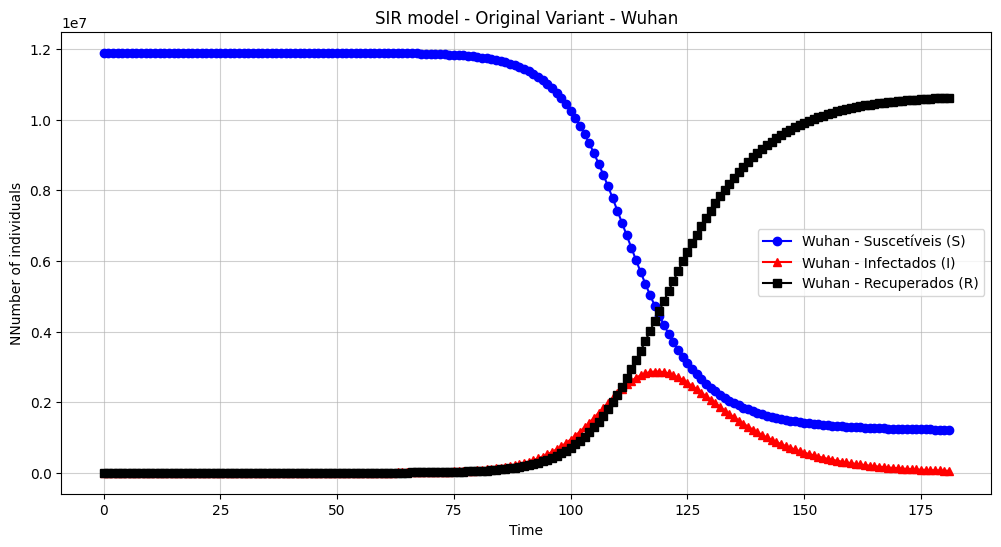

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros do modelo
N = 1.19e7            # população total de SP
lambda_ = 0.25       # taxa de transmissão - 1/4
gamma = 0.1         # taxa de recuperação - 1/10
Delta_t = 1       # passo de tempo
T = 182            # tempo total de simulação - 6 meses

# Vetor de tempo
t = np.arange(0, T, Delta_t)

# Vetores para S, I e R
Wuhan_S = np.zeros(len(t))
Wuhan_I = np.zeros(len(t))
Wuhan_R = np.zeros(len(t))

# Condições iniciais
Wuhan_S[0] = N - 1 # população total - 1 infectado
Wuhan_I[0] = 1 # quantidade de infectados
Wuhan_R[0] = 0

# Iteração discreta (equações de diferenças - Euler method)
for k in range(len(t)-1):
    Wuhan_S[k+1] = Wuhan_S[k] - (lambda_/N)*Wuhan_S[k]*Wuhan_I[k]*Delta_t
    Wuhan_I[k+1] = Wuhan_I[k] + ((lambda_/N)*Wuhan_S[k]*Wuhan_I[k] - gamma*Wuhan_I[k]) * Delta_t
    Wuhan_R[k+1] = Wuhan_R[k] + gamma*Wuhan_I[k]*Delta_t

# Plotando os resultados
plt.figure(figsize=(12,6) )
plt.plot(t, Wuhan_S,"bo-", label= 'Wuhan - Susceptible (S)')
plt.plot(t, Wuhan_I,"r^-", label='Wuhan - Infected (I)')
plt.plot(t, Wuhan_R,"ks-", label= 'Wuhan - Recovered (R)')
plt.xlabel('Time')
plt.ylabel('Number of individuals')
plt.title('SIR model - Original Variant - Wuhan')
plt.legend()
plt.grid(True, alpha=0.6)
plt.show()

# **SIR model - Alfa** 

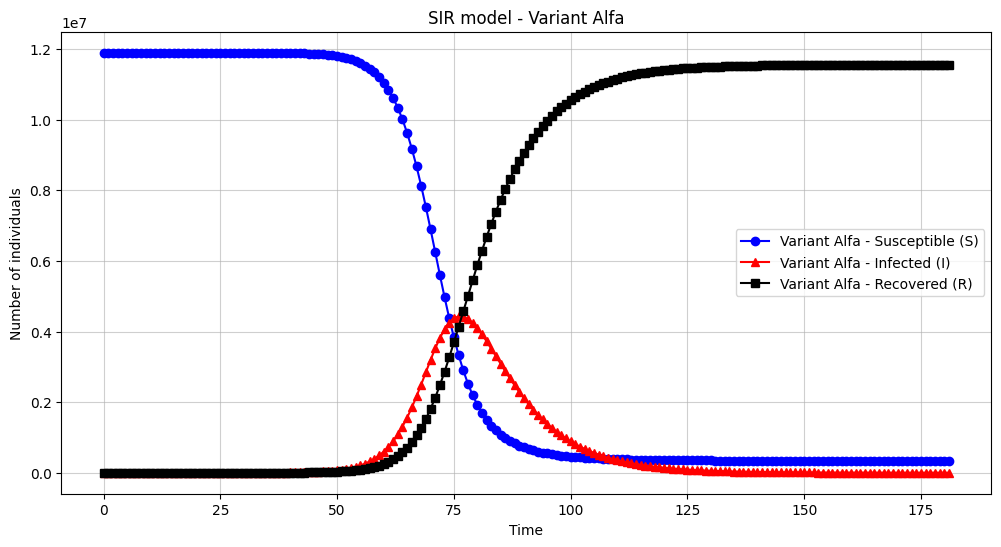

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros do modelo
N = 1.19e7            # população total de SP
lambda_ = 0.35       # taxa de transmissão - 1/4
gamma = 0.1         # taxa de recuperação - 1/10
Delta_t = 1       # passo de tempo
T = 182            # tempo total de simulação - 6 meses

# Vetor de tempo
t = np.arange(0, T, Delta_t)

# Vetores para S, I e R
alfa_S = np.zeros(len(t))
alfa_I = np.zeros(len(t))
alfa_R = np.zeros(len(t))

# Condições iniciais
alfa_S[0] = N - 1 # população total - 1 infectado
alfa_I[0] = 1 # quantidade de infectados
alfa_R[0] = 0

# Iteração discreta (equações de diferenças - Euler method)
for k in range(len(t)-1):
    alfa_S[k+1] = alfa_S[k] - (lambda_/N)*alfa_S[k]*alfa_I[k]*Delta_t
    alfa_I[k+1] = alfa_I[k] + ((lambda_/N)*alfa_S[k]*alfa_I[k] - gamma*alfa_I[k]) * Delta_t
    alfa_R[k+1] = alfa_R[k] + gamma*alfa_I[k]*Delta_t

# Plotando os resultados
plt.figure(figsize=(12,6) )
plt.plot(t, alfa_S,"bo-", label= 'Variant Alfa - Susceptible (S)')
plt.plot(t, alfa_I,"r^-", label='Variant Alfa - Infected (I)')
plt.plot(t, alfa_R,"ks-", label= 'Variant Alfa - Recovered (R)')
plt.xlabel('Time')
plt.ylabel('Number of individuals')
plt.title('SIR model - Variant Alfa')
plt.legend()
plt.grid(True, alpha=0.6)
plt.show()

# **SIR model - Delta** 

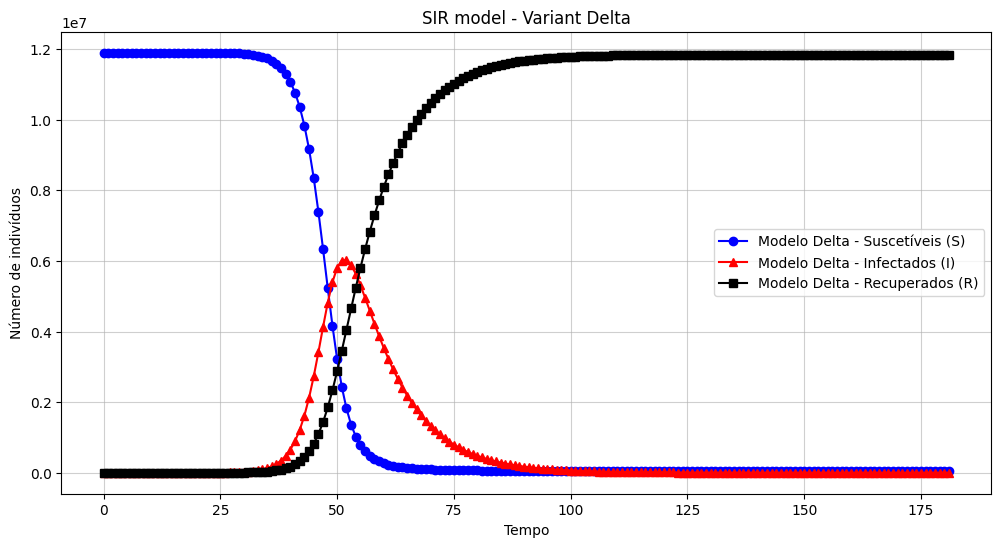

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros do modelo
N = 1.19e7            # população total de SP
lambda_ = 0.5       # taxa de transmissão - 1/4
gamma = 0.1         # taxa de recuperação - 1/10
Delta_t = 1       # passo de tempo
T = 182            # tempo total de simulação - 6 meses

# Vetor de tempo
t = np.arange(0, T, Delta_t)

# Vetores para S, I e R
delta_S = np.zeros(len(t))
delta_I = np.zeros(len(t))
delta_R = np.zeros(len(t))

# Condições iniciais
delta_S[0] = N - 1 # população total - 1 infectado
delta_I[0] = 1 # quantidade de infectados
delta_R[0] = 0

# Iteração discreta (equações de diferenças - Euler method)
for k in range(len(t)-1):
    delta_S[k+1] = delta_S[k] - (lambda_/N)*delta_S[k]*delta_I[k]*Delta_t
    delta_I[k+1] = delta_I[k] + ((lambda_/N)*delta_S[k]*delta_I[k] - gamma*delta_I[k]) * Delta_t
    delta_R[k+1] = delta_R[k] + gamma*delta_I[k]*Delta_t

# Plotando os resultados
plt.figure(figsize=(12,6) )
plt.plot(t, delta_S,"bo-", label= 'Modelo Delta - Suscetíveis (S)')
plt.plot(t, delta_I,"r^-", label='Modelo Delta - Infectados (I)')
plt.plot(t, delta_R,"ks-", label= 'Modelo Delta - Recuperados (R)')
plt.xlabel('Tempo')
plt.ylabel('Número de indivíduos')
plt.title('SIR model - Variant Delta')
plt.legend()
plt.grid(True, alpha=0.6)
plt.show()

# **SIR model - Omicron** 

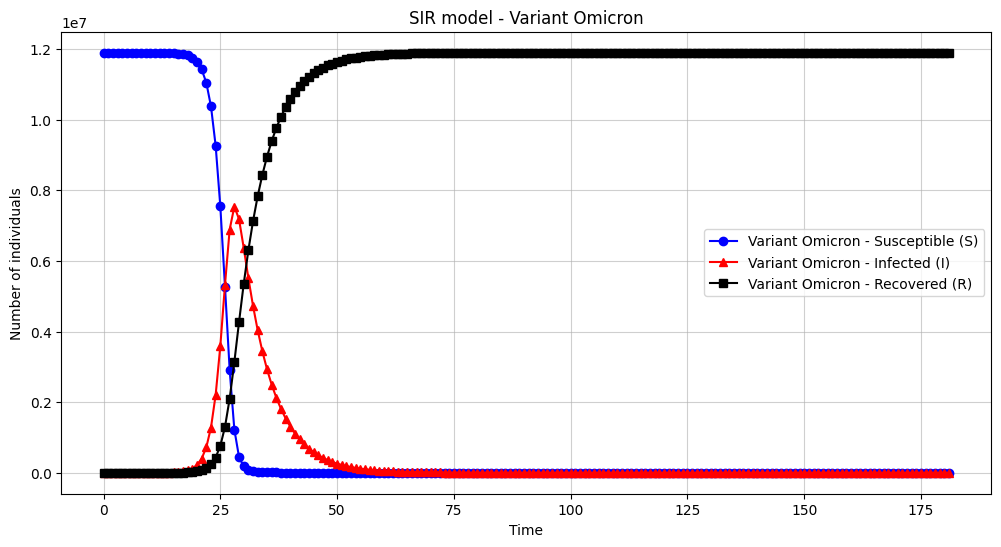

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros do modelo
N = 1.19e7            # população total de SP
lambda_ = 1.0       # taxa de transmissão - 1/4
gamma = 0.15         # taxa de recuperação - 1/10
Delta_t = 1       # passo de tempo
T = 182            # tempo total de simulação - 6 meses

# Vetor de tempo
t = np.arange(0, T, Delta_t)

# Vetores para S, I e R
omicron_S = np.zeros(len(t))
omicron_I = np.zeros(len(t))
omicron_R = np.zeros(len(t))

# Condições iniciais
omicron_S[0] = N - 1 # população total - 1 infectado
omicron_I[0] = 1 # quantidade de infectados
omicron_R[0] = 0

# Iteração discreta (equações de diferenças - Euler method)
for k in range(len(t)-1):
    omicron_S[k+1] = omicron_S[k] - (lambda_/N)*omicron_S[k]*omicron_I[k]*Delta_t
    omicron_I[k+1] = omicron_I[k] + ((lambda_/N)*omicron_S[k]*omicron_I[k] - gamma*omicron_I[k]) * Delta_t
    omicron_R[k+1] = omicron_R[k] + gamma*omicron_I[k]*Delta_t

# Plotando os resultados
plt.figure(figsize=(12,6) )
plt.plot(t, omicron_S,"bo-", label= 'Variant Omicron - Susceptible (S)')
plt.plot(t, omicron_I,"r^-", label='Variant Omicron - Infected (I)')
plt.plot(t, omicron_R,"ks-", label= 'Variant Omicron - Recovered (R)')
plt.xlabel('Time')
plt.ylabel('Number of individuals')
plt.title('SIR model - Variant Omicron')
plt.legend()
plt.grid(True, alpha=0.6)
plt.show()

# **SIR model: Empirical vs. Theoretical** 

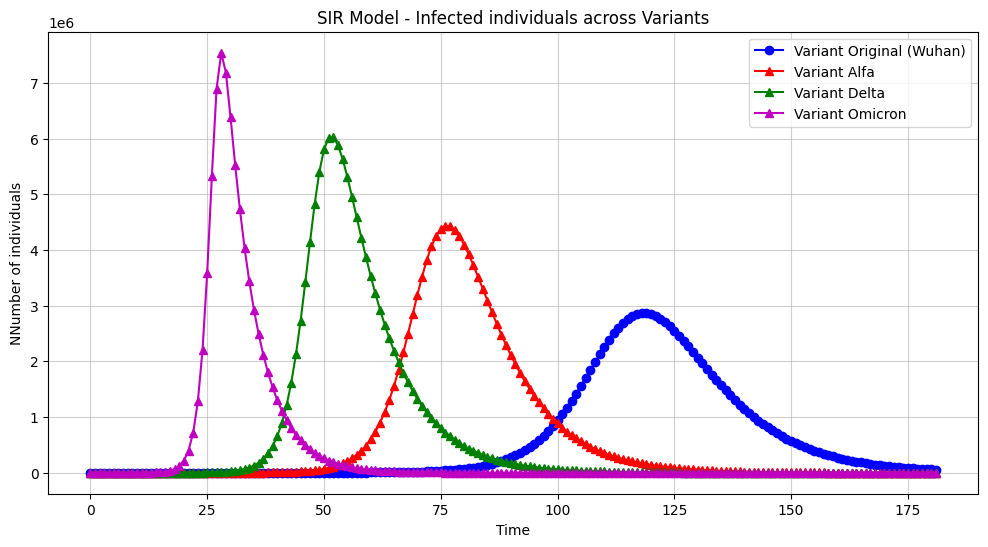

In [29]:
# Plotando os resultados
plt.figure(figsize=(12,6))
plt.plot(t, Wuhan_I,"bo-", label='Variant Original (Wuhan)')
plt.plot(t, alfa_I,"r^-", label='Variant Alfa')
plt.plot(t, delta_I,"g^-", label='Variant Delta')
plt.plot(t, omicron_I,"m^-", label='Variant Omicron')
plt.xlabel('Time')
plt.ylabel('NNumber of individuals')
plt.title('SIR Model - Infected individuals across Variants')
plt.legend()
plt.grid(True, alpha=0.6)
plt.show()